# Clasificacion de resenas de productos (Amazon Reviews)

Objetivo: clasificar resenas como positivas (1) o negativas (0) a partir del texto.

Pipeline:
1. Carga y exploracion inicial.
2. Limpieza y preprocesamiento de texto.
3. Vectorizacion TF-IDF.
4. Entrenamiento y evaluacion de modelos.
5. Comparacion y visualizacion.
6. t-SNE para visualizacion.
7. Interpretacion y conclusiones.

In [17]:
import bz2
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from IPython.display import display, Markdown
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE

# Recursos NLTK requeridos
nltk.download("stopwords")

sns.set(style="whitegrid")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\palaG\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [31]:
# 1. Carga del dataset (.bz2)
train_path = "..\\datasets\\Ejercicio 3\\train.ft.txt.bz2"
test_path = "..\\datasets\\Ejercicio 3\\test.ft.txt.bz2"

def load_fasttext_bz2(path):
    reviews = []
    sentiments = []
    with bz2.open(path, "rt", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith("__label__"):
                parts = line.split(" ", 1)
                label = parts[0]
                text = parts[1] if len(parts) > 1 else ""
                if label.endswith("1"):
                    sentiment = 0
                elif label.endswith("2"):
                    sentiment = 1
                else:
                    sentiment = None
                reviews.append(text)
                sentiments.append(sentiment)
            else:
                # Fallback por si el archivo fuera tab-separado
                parts = line.split("\t")
                if len(parts) >= 2:
                    text = parts[0]
                    try:
                        sentiment = int(parts[1])
                    except ValueError:
                        sentiment = None
                    reviews.append(text)
                    sentiments.append(sentiment)
    df = pd.DataFrame({"review": reviews, "sentiment": sentiments})
    df = df.dropna(subset=["sentiment"]).copy()
    df["sentiment"] = df["sentiment"].astype(int)
    return df

def stratified_sample_df(df, n, label_col="sentiment", random_state=42):
    if n >= len(df):
        return df.reset_index(drop=True)
    train_size = n / len(df)
    df_sample, _ = train_test_split(
        df,
        train_size=train_size,
        stratify=df[label_col],
        random_state=random_state,
)
    return df_sample.reset_index(drop=True)

df_train = load_fasttext_bz2(train_path)
df_test = load_fasttext_bz2(test_path)

# Ajusta los tamanos para acelerar el flujo
USE_SAMPLE = True
SAMPLE_TRAIN = 30000
SAMPLE_TEST = 15000

if USE_SAMPLE:
    df_train = stratified_sample_df(df_train, SAMPLE_TRAIN)
    df_test = stratified_sample_df(df_test, SAMPLE_TEST)

df_train.head()

,review,sentiment
0,"Important, well made but unengaging: Spurred o...",0
1,Genius unshrouded!: What an amazing book! Like...,1
2,alice in wonderland 1985: I've been waiting fo...,1
3,"Genius: As usual, Garrett Freymann-Weyr had me...",1
4,Dragon Quest VIII: Journey of the Cursed King ...,1


## 1. Carga y exploracion inicial (EDA)

Se exploran dimensiones, tipos de datos, balance de clases y ejemplos de resenas.

Train shape: (30000, 2)
Test shape: (15000, 2)

Tipos de datos:


review         str
sentiment    int64
dtype: object


Distribucion de clases (train):


sentiment
0    15000
1    15000
Name: count, dtype: int64

C:\Users\palaG\AppData\Local\Temp\ipykernel_8028\64176584.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="sentiment", data=df_train, palette="pastel")


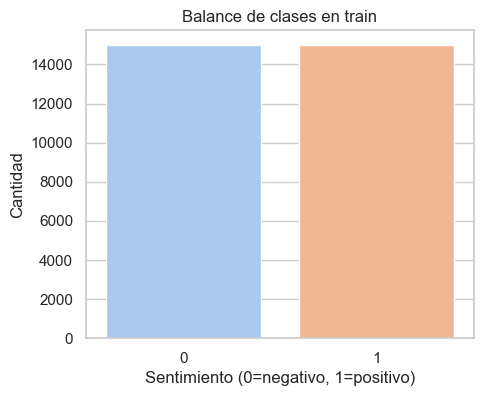


Ejemplos de resenas con sentimiento 0:
1. Don't waste your money!: Fellow Sailors:Please don't waste your money on this latest book by Van Sant!Let me explain. This book is a MAJOR rehash of Van Sant's earlier "Gentleman's Guide . . ." but does not contain nearly as much. If you don't have his Geltleman's Guide, then buy that. Van Sant is VERY knowledgeable and if you can stand for and get by his pompous tone and condescending egocentric 
2. A Pox on celluloid - Zero stars!: I can't wait to see MST 3000 shred this mess. I felt like I was watching a two hour exploding beer commercial full of macho men, trampy vixens and insipid dialogue. The film is perfect for the Beavis and Butthead crowd which shot this film to #1! Tastes Great! Less Filling! We're #1!
3. Horrible Learning Experience: Product came broken, the tiles are too small. Dangerous if children place these tiles in theri mouth, it does'nt matter what age! it's still dangerous. Some words are even faded! Overall horrible produ

In [32]:
print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

print("\nTipos de datos:")
display(df_train.dtypes)

class_counts = df_train["sentiment"].value_counts().sort_index()
print("\nDistribucion de clases (train):")
display(class_counts)

plt.figure(figsize=(5, 4))
sns.countplot(x="sentiment", data=df_train, palette="pastel")
plt.title("Balance de clases en train")
plt.xlabel("Sentimiento (0=negativo, 1=positivo)")
plt.ylabel("Cantidad")
plt.show()

def show_examples(df, label, n=3):
    subset = df[df["sentiment"] == label]
    n = min(n, len(subset))
    print(f"\nEjemplos de resenas con sentimiento {label}:")
    for i, text in enumerate(subset["review"].sample(n, random_state=42).tolist(), 1):
        print(f"{i}. {text[:400]}")

show_examples(df_train, 0)
show_examples(df_train, 1)

## 2. Limpieza y preprocesamiento de texto

Se aplican: minusculas, limpieza de caracteres, stopwords, tokenizacion con regex y stemming (PorterStemmer). Para acelerar, la limpieza completa se integra en el vectorizador y solo se muestra una muestra.

In [33]:
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()
token_pattern = re.compile(r"[a-z]+")

def stem_analyzer(text):
    if not isinstance(text, str):
        text = str(text)
    text = text.lower()
    tokens = token_pattern.findall(text)
    return [
        stemmer.stem(tok)
        for tok in tokens
        if tok not in stop_words and len(tok) > 1
    ]

def clean_text(text):
    return " ".join(stem_analyzer(text))

# Aplica la limpieza optimizada a todo el dataset
df_train["clean_review"] = df_train["review"].apply(clean_text)
df_test["clean_review"] = df_test["review"].apply(clean_text)
display(df_train[["review", "clean_review"]].head())

,review,clean_review
0,"Important, well made but unengaging: Spurred o...",import well made unengag spur brilliant review...
1,Genius unshrouded!: What an amazing book! Like...,geniu unshroud amaz book like modern day prome...
2,alice in wonderland 1985: I've been waiting fo...,alic wonderland wait year see movi dvd daughte...
3,"Genius: As usual, Garrett Freymann-Weyr had me...",geniu usual garrett freymann weyr captiv alrea...
4,Dragon Quest VIII: Journey of the Cursed King ...,dragon quest viii journey curs king strategi g...


## 3. Vectores TF-IDF

TF-IDF pondera los terminos por su frecuencia y su capacidad de discriminar documentos, reduciendo el peso de palabras muy comunes.

In [34]:
vectorizer = TfidfVectorizer(
    analyzer=stem_analyzer,
    max_features=30000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    dtype=np.float32,
)
X_train = vectorizer.fit_transform(df_train["clean_review"])
X_test = vectorizer.transform(df_test["clean_review"])
y_train = df_train["sentiment"].values
y_test = df_test["sentiment"].values

print("Matriz TF-IDF (train):", X_train.shape)

c:\Users\palaG\OneDrive\Analisis de datos\Machine learning\entrega4\venv\Lib\site-packages\sklearn\feature_extraction\text.py:542: UserWarning: The parameter 'ngram_range' will not be used since 'analyzer' is callable'
  warnings.warn(


Matriz TF-IDF (train): (30000, 19181)


## 4. Entrenamiento de modelos

Se entrenan Naive Bayes, Regresion Logistica y SVM lineal con el set de entrenamiento.

In [35]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(),
}

metrics_rows = []
conf_matrices = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    metrics_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, preds),
        "f1_macro": f1_score(y_test, preds, average="macro"),
        "f1_weighted": f1_score(y_test, preds, average="weighted"),
    })
    conf_matrices[name] = confusion_matrix(y_test, preds)


## 5. Evaluacion y comparacion de modelos

Se construye una tabla comparativa y se visualizan las matrices de confusion.

In [36]:
results_df = (
    pd.DataFrame(metrics_rows)
    .set_index("model")
    .sort_values("f1_weighted", ascending=False)
)
results_df

,accuracy,f1_macro,f1_weighted
model,,,
Logistic Regression,0.866333,0.866320,0.866320
Linear SVM,0.856067,0.856054,0.856054
Naive Bayes,0.817533,0.817525,0.817525


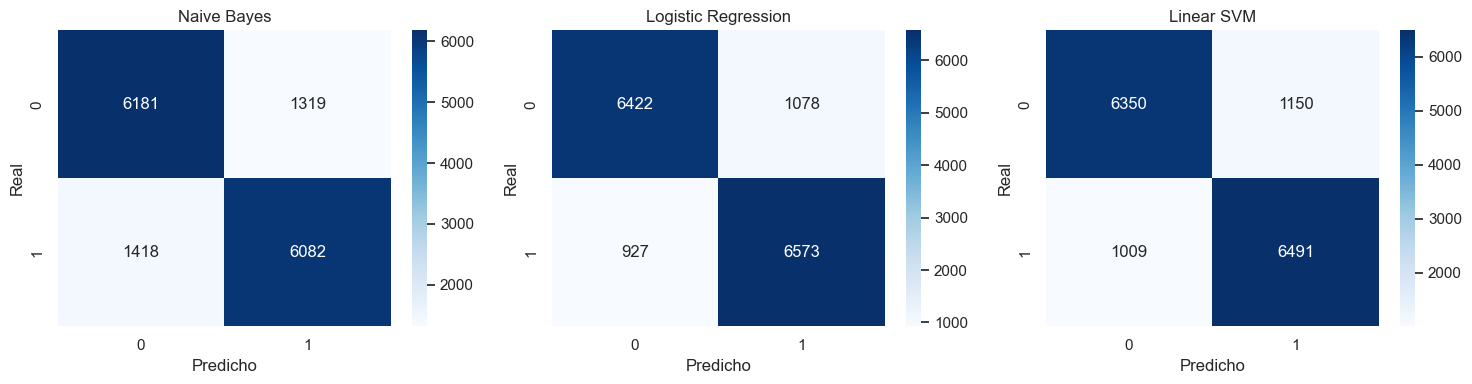

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, cm) in zip(axes, conf_matrices.items()):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

## 6. Reduccion de dimensionalidad con t-SNE

Se usa una muestra para reducir costos y visualizar la separacion entre clases.

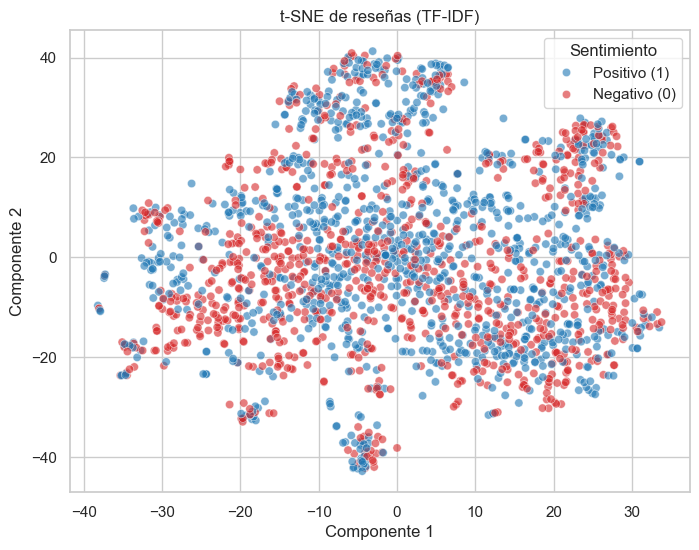

In [38]:
sample_size = min(2000, X_train.shape[0])
rng = np.random.RandomState(42)
sample_idx = rng.choice(X_train.shape[0], size=sample_size, replace=False)
X_sample = X_train[sample_idx]
y_sample = y_train[sample_idx]

# Reducir dimensionalidad antes de t-SNE para hacerlo mas eficiente
svd = TruncatedSVD(n_components=50, random_state=42)
X_reduced = svd.fit_transform(X_sample)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate="auto", init="pca")
X_tsne = tsne.fit_transform(X_reduced)

plt.figure(figsize=(8, 6))
sent_map = {0: "Negativo (0)", 1: "Positivo (1)"}
y_sample_named = pd.Series(y_sample).map(sent_map)

sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=y_sample_named,
    palette={"Negativo (0)": "tab:red", "Positivo (1)": "tab:blue"},
    alpha=0.6,
    legend="full",
)
plt.title("t-SNE de reseñas (TF-IDF)")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.legend(title="Sentimiento")
plt.show()

## 7. Interpretacion y conclusiones

La interpretacion se genera a partir de las metricas obtenidas en el bloque anterior y la matriz de confusion del mejor modelo.

In [40]:
best_model = results_df.index[0]
best_row = results_df.loc[best_model]
cm_best = conf_matrices.get(best_model)

if cm_best is not None and cm_best.shape == (2, 2):
    tn, fp, fn, tp = cm_best.ravel()
    if fp > fn:
        bias_msg = "Tiende a predecir positivo con mas frecuencia (FP > FN)."
    elif fn > fp:
        bias_msg = "Tiende a predecir negativo con mas frecuencia (FN > FP)."
    else:
        bias_msg = "FP y FN estan equilibrados."
    cm_line = f"TN={tn}, FP={fp}, FN={fn}, TP={tp}. {bias_msg}"
else:
    cm_line = "Matriz de confusion no disponible o con forma inesperada."

ranking_lines = []
for model_name, row in results_df.iterrows():
    ranking_lines.append(
        f"- {model_name}: accuracy={row['accuracy']:.3f}, "
        f"f1_macro={row['f1_macro']:.3f}, f1_weighted={row['f1_weighted']:.3f}"
    )

summary_md = "\n".join([
    "**Conclusiones basadas en resultados**",
    f"- Tamano de muestra: train={len(df_train)}, test={len(df_test)}.",
    (
        f"- Mejor modelo: {best_model} "
        f"(accuracy={best_row['accuracy']:.3f}, "
        f"f1_macro={best_row['f1_macro']:.3f}, "
        f"f1_weighted={best_row['f1_weighted']:.3f})."
    ),
    "- Ranking por F1 ponderado:",
    *ranking_lines,
    f"- Matriz de confusion ({best_model}): {cm_line}",
    ("- Limitaciones: el texto limpio puede perder matices (negaciones, sarcasmo) "
     "y TF-IDF no captura contexto."),
    ("- Posibles mejoras: ajuste de hiperparametros, n-gramas mas ricos, "
     "embeddings (Word2Vec, GloVe, BERT) y mas datos."),
])

display(Markdown(summary_md))

**Conclusiones basadas en resultados**
- Tamano de muestra: train=30000, test=15000.
- Mejor modelo: Logistic Regression (accuracy=0.866, f1_macro=0.866, f1_weighted=0.866).
- Ranking por F1 ponderado:
- Logistic Regression: accuracy=0.866, f1_macro=0.866, f1_weighted=0.866
- Linear SVM: accuracy=0.856, f1_macro=0.856, f1_weighted=0.856
- Naive Bayes: accuracy=0.818, f1_macro=0.818, f1_weighted=0.818
- Matriz de confusion (Logistic Regression): TN=6422, FP=1078, FN=927, TP=6573. Tiende a predecir positivo con mas frecuencia (FP > FN).
- Limitaciones: el texto limpio puede perder matices (negaciones, sarcasmo) y TF-IDF no captura contexto.
- Posibles mejoras: ajuste de hiperparametros, n-gramas mas ricos, embeddings (Word2Vec, GloVe, BERT) y mas datos.